<a href="https://colab.research.google.com/github/dev-ssr/team9_PyCoders_PythonHackathon_MAY2026/blob/main/Team9_PyCoders_Category4_PredictiveAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Question** Can a machine learning/deep learning model forecast future glucose values using historical glucose readings, heart rate, physical activity, calorie expenditure, and insulin delivery data?

Objective

Predict glucose 30–60 minutes into the future.

We built a regression model because:
* the target variable (future_glucose) is continuous,
* and the goal is to predict an exact future glucose value.

**Helps prevent:**

* Hypoglycemia
* Hyperglycemia
* Dangerous glucose swings

In [3]:
# from google.colab import drive
# drive.mount('/content/drive')

Mounted at /content/drive


from google.colab import drive
drive.mount('/content/drive')

In [4]:
import pandas as pd
#path = '/content/drive/MyDrive/clean.csv'
path = 'clean.csv'
df = pd.read_csv(path, parse_dates=['time'])
df.head()

,time,glucose,calories,heart_rate,steps,basal_rate,bolus_volume_delivered,carb_input,Patient_ID,Age,Gender,Race,Average Sleep Duration (hrs),Sleep Quality (1-10),% with Sleep Disturbances
0,2020-01-17 00:00:00,40.00,15.04,96.37,8.0,0.035,0.0,1.0,HUPA0023P,74,Female,Black,5.1,6.8,40
1,2020-01-17 00:05:00,41.33,8.32,91.40,0.0,0.035,0.0,0.0,HUPA0023P,74,Female,Black,5.1,6.8,40
2,2020-01-17 00:10:00,42.67,7.58,85.99,0.0,0.035,0.0,0.0,HUPA0023P,74,Female,Black,5.1,6.8,40
3,2020-01-17 00:15:00,44.00,7.34,82.43,0.0,0.035,0.0,0.0,HUPA0023P,74,Female,Black,5.1,6.8,40
4,2020-01-17 00:20:00,50.00,7.58,78.82,0.0,0.035,0.0,0.0,HUPA0023P,74,Female,Black,5.1,6.8,40


In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense

In [6]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


In [7]:
df = df.sort_values(['Patient_ID', 'time'])

In [8]:
features = [
    'glucose',
    'heart_rate',
    'steps',
    'calories',
    'basal_rate',
    'bolus_volume_delivered',
    'carb_input'
]

In [11]:
split_index = int(len(df) * 0.8)

train_df = df.iloc[:split_index]
test_df = df.iloc[split_index:]

In [12]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaler.fit(train_df[features])

train_scaled = scaler.transform(train_df[features])
test_scaled = scaler.transform(test_df[features])


In [13]:
sequence_length = 12
future_steps = 6   # 30 mins ahead

def create_sequences(data):

    X = []
    y = []

    for i in range(sequence_length,
                   len(data) - future_steps):

        X.append(
            data[i-sequence_length:i]
        )

        y.append(
            data[i + future_steps, 0]
        )

    return np.array(X), np.array(y)
X_train, y_train = create_sequences(train_scaled)

X_test, y_test = create_sequences(test_scaled)

In [14]:
model = Sequential()

model.add(
    GRU(
        64,
        input_shape=(
            X_train.shape[1],
            X_train.shape[2]
        )
    )
)

model.add(Dense(32))
model.add(Dense(1))

model.compile(
    optimizer='adam',
    loss='mse'
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [15]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/20
6961/6961 ━━━━━━━━━━━━━━━━━━━━ 78s 11ms/step - loss: 0.0030 - val_loss: 0.0016
Epoch 2/20
6961/6961 ━━━━━━━━━━━━━━━━━━━━ 74s 11ms/step - loss: 0.0028 - val_loss: 0.0017
Epoch 3/20
6961/6961 ━━━━━━━━━━━━━━━━━━━━ 82s 11ms/step - loss: 0.0026 - val_loss: 0.0016
Epoch 4/20
6961/6961 ━━━━━━━━━━━━━━━━━━━━ 74s 11ms/step - loss: 0.0026 - val_loss: 0.0016
Epoch 5/20
6961/6961 ━━━━━━━━━━━━━━━━━━━━ 75s 11ms/step - loss: 0.0025 - val_loss: 0.0016
Epoch 6/20
6961/6961 ━━━━━━━━━━━━━━━━━━━━ 76s 11ms/step - loss: 0.0025 - val_loss: 0.0016
Epoch 7/20
6961/6961 ━━━━━━━━━━━━━━━━━━━━ 75s 11ms/step - loss: 0.0024 - val_loss: 0.0016
Epoch 8/20
6961/6961 ━━━━━━━━━━━━━━━━━━━━ 81s 11ms/step - loss: 0.0024 - val_loss: 0.0015
Epoch 9/20
6961/6961 ━━━━━━━━━━━━━━━━━━━━ 82s 11ms/step - loss: 0.0023 - val_loss: 0.0015
Epoch 10/20
6961/6961 ━━━━━━━━━━━━━━━━━━━━ 82s 11ms/step - loss: 0.0023 - val_loss: 0.0014
Epoch 11/20
6961/6961 ━━━━━━━━━━━━━━━━━━━━ 74s 11ms/step - loss: 0.0023 - val_loss: 0.0014
Epoch 12

In [16]:
predictions = model.predict(X_test)

1934/1934 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step


In [17]:
dummy = np.zeros((len(predictions), len(features)))
dummy[:, 0] = predictions.flatten()

predictions_actual = scaler.inverse_transform(dummy)[:, 0]

dummy2 = np.zeros((len(y_test), len(features)))
dummy2[:, 0] = y_test

y_test_actual = scaler.inverse_transform(dummy2)[:, 0]

In [18]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

mae = mean_absolute_error(
    y_test_actual,
    predictions_actual
)

rmse = np.sqrt(
    mean_squared_error(
        y_test_actual,
        predictions_actual
    )
)

r2 = r2_score(
    y_test_actual,
    predictions_actual
)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 10.76975760195479
RMSE: 15.519174785250222
R²: 0.8591334974009301


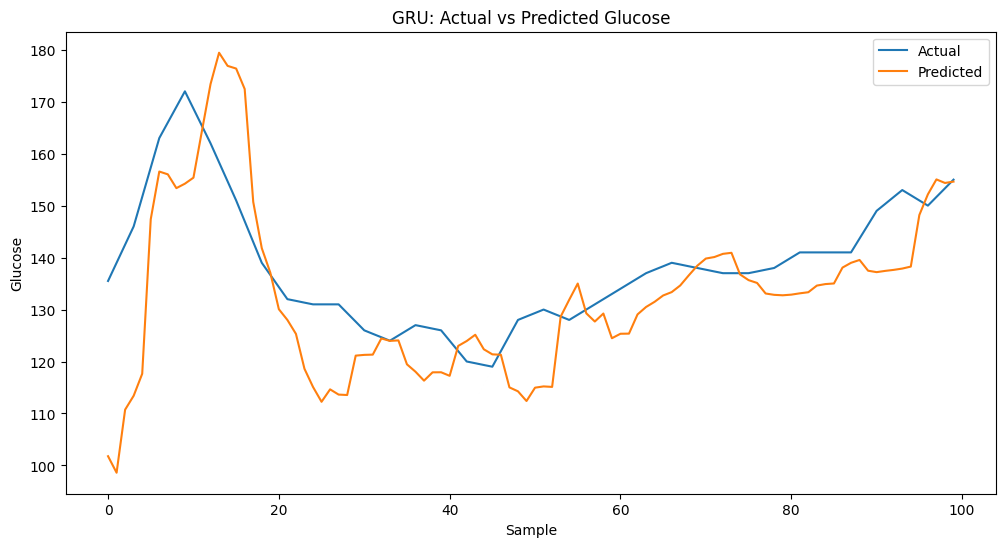

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    y_test_actual[:100],
    label='Actual'
)

plt.plot(
    predictions_actual[:100],
    label='Predicted'
)

plt.title("GRU: Actual vs Predicted Glucose")

plt.xlabel("Sample")
plt.ylabel("Glucose")

plt.legend()

plt.show()

The goal of the regression model was to predict future glucose levels using physiological, activity, and insulin-related features from the HUPA-UC diabetes dataset.

target variable : future_glucose


**Features Used**
* glucose
* heart_rate
* steps
* calories
* basal_rate
* bolus_volume_delivered
* carb_input

These markers were chosen because they influence glucose behavior through insulin delivery, physical activity, energy expenditure, and physiological response.

**Model Used**

A GRU regression model was used.

GRU was selected because glucose data is sequential, and GRU models are designed to learn time-dependent patterns in time-series data.

**Model Evaluation Metrics**

The model was evaluated using:

* MAE
* RMSE
* R²

These are appropriate because the task predicts a continuous glucose value.

**Results**

The GRU model achieved:

* MAE: 10.77
* RMSE: 15.52
* R²: 0.859

**Interpretation**

The MAE of 10.77 means the model’s predictions were off by about 10.77 mg/dL on average.

The RMSE of 15.52 shows that the model handled most glucose fluctuations well, though larger errors still occurred during sharp rises or drops.

The R² value of 0.859 means the model explained about 85.9% of the variation in future glucose levels.

**Visualization Summary**

The actual vs predicted glucose plot showed that the GRU model followed the overall glucose trend closely.

The model captured:

rising glucose patterns,
falling glucose patterns,
and medium-term glucose changes.

However, it still showed some lag during sudden glucose spikes or drops.

**Medical Interpretation**

The results suggest that future glucose levels can be reasonably predicted using historical physiological and insulin-related data.

This supports the use of machine learning for:

proactive glucose monitoring,
early warning systems,
and personalized diabetes management.


**Final Conclusion**

The GRU regression model performed strongly for future glucose prediction. Compared with traditional models such as XGBoost, GRU was better suited for this task because it captured temporal dependencies in glucose data.

Overall, the model demonstrates the potential of deep learning for predictive diabetes care.